# [Title of the report]


[It is ideal to include a table of contents here to organise content with the right level of heading and sub-headings; makes it much easier to read for your audience. Use the right level of headings (Heading 1, Heading 2 etc.) to preserve hierarchy
]

Impt note: The template only provides sample blocks to ensure you cover the basic requirements of this assignment; you are free to adapt it to your need as required.

## Introduction

[Provide a short paragraph providing background to your analysis, explaining your aims and context. Include specific questions of inquiry, if any]

## Data Ingestion

[Describe your input data set, and provide a high-level explanation of the steps in your code]

In [2]:
#Add code to ingest data
import os
import glob
import pandas as pd

# Path to your local folder containing PDFs
pdf_folder = r"D:\NLP project\submissions_2025 federal election"

# Get list of all PDF files in the folder
pdf_files = glob.glob(os.path.join(pdf_folder, "*.pdf"))

print(f"Found {len(pdf_files)} PDF files.")


Found 299 PDF files.


In [3]:
# Number of submissions
print("Total submissions:", len(pdf_files))

# Check first few entries
print(pdf_files[:5])

df_files = pd.DataFrame({
    "filename": pdf_files
})

Total submissions: 299
['D:\\NLP project\\submissions_2025 federal election\\Sub001 - Bob McMullan.pdf', 'D:\\NLP project\\submissions_2025 federal election\\Sub002 - Dr Sheppard.pdf', 'D:\\NLP project\\submissions_2025 federal election\\Sub003 - Grattan Institute.pdf', 'D:\\NLP project\\submissions_2025 federal election\\Sub004 - Australian Electoral Commission.pdf', 'D:\\NLP project\\submissions_2025 federal election\\Sub005 - The Australia Institute.pdf']


In [4]:
# Lists to store results
import pdfplumber
texts = []
metadata = []

# Extract text from each PDF
for file in pdf_files:
    try:
        with pdfplumber.open(file) as pdf:
            text = ""
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
            texts.append(text)
            metadata.append(os.path.basename(file))
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Create DataFrame with text
df = pd.DataFrame({
    "filename": metadata,
    "text": texts
})

# Quick info
print(f"Extracted text from {len(df)} PDFs")
print(df.head())

Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because No

Extracted text from 299 PDFs
                                       filename  \
0                     Sub001 - Bob McMullan.pdf   
1                      Sub002 - Dr Sheppard.pdf   
2                Sub003 - Grattan Institute.pdf   
3  Sub004 - Australian Electoral Commission.pdf   
4          Sub005 - The Australia Institute.pdf   

                                                text  
0  Inquiry into the 2025 federal election\nSubmis...  
1  Inquiry into the 2025 federal election\nSubmis...  
2  Inquiry into the 2025 federal election\nSubmis...  
3  Inquiry into the 2025 federal election\nSubmis...  
4  Inquiry into the 2025 federal election\nSubmis...  


In [5]:
pickle_file = r"D:\NLP project\submissions_text_v2.pkl"
df.to_pickle(pickle_file)

print("Saved successfully")

Saved successfully


In [6]:
import pandas as pd

# Load the DataFrame from pickle
df = pd.read_pickle(r"D:\NLP project\submissions_text.pkl")
print(f"Loaded DataFrame with {len(df)} entries")
print(df.head())

Loaded DataFrame with 299 entries
                                       filename  \
0                     Sub001 - Bob McMullan.pdf   
1                      Sub002 - Dr Sheppard.pdf   
2                Sub003 - Grattan Institute.pdf   
3  Sub004 - Australian Electoral Commission.pdf   
4          Sub005 - The Australia Institute.pdf   

                                                text  
0  Inquiry into the 2025 federal election\nSubmis...  
1  Inquiry into the 2025 federal election\nSubmis...  
2  Inquiry into the 2025 federal election\nSubmis...  
3  Inquiry into the 2025 federal election\nSubmis...  
4  Inquiry into the 2025 federal election\nSubmis...  


### 1. Basic Analysis

[Add sub-headers as needed to highlight the kinds of analysis done]

In [7]:
# Create a word count column
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Show first 10
print(df[['filename', 'word_count']].head(10))

# Summary statistics
print(df['word_count'].describe())

                                       filename  word_count
0                     Sub001 - Bob McMullan.pdf         662
1                      Sub002 - Dr Sheppard.pdf         782
2                Sub003 - Grattan Institute.pdf        4849
3  Sub004 - Australian Electoral Commission.pdf       10131
4          Sub005 - The Australia Institute.pdf       12117
5                    Sub006 - Andrew Murray.pdf         338
6                  Sub007 - Genevieve Grant.pdf         646
7                      Sub008 - Richard Ure.pdf         606
8                     Sub009 - Barry Searle.pdf         333
9                    Sub010 - Name withheld.pdf         130
count      299.000000
mean      1978.906355
std       3795.866544
min          8.000000
25%        344.500000
50%        831.000000
75%       1822.000000
max      36258.000000
Name: word_count, dtype: float64


In [8]:
df[df['word_count'] < 50][['filename', 'word_count']]

,filename,word_count
14,Sub015 - Name withheld.pdf,8
15,Sub016 - Name withheld.pdf,8
32,Sub033 - Name withheld.pdf,8
51,Sub052 - John Ferguson.pdf,8
56,Sub057 - Tony Robinson.pdf,8
69,Sub072 - Lynn Lawson.pdf,8
74,Sub077 - Name withheld.pdf,8
76,Sub079 - Jane Johnson.pdf,8
116,Sub119 - Name Withheld.pdf,40
147,Sub148 - Advance Australia.pdf,32


In [9]:
row = df[df['filename'].str.contains('SupSub093.1')].iloc[0]
print(row['text'])

Inquiry into the 2025 federal election
Submission 93 - Supplementary Submission
Inquiry into the 2025 federal election
Submission 93 - Supplementary Submission



In [10]:
row = df[df['filename'].str.contains('Sub119')].iloc[0]
print(row['text'])

Inquiry into the 2025 federal election
Submission 119
Inquiry into the 2025 federal election
Submission 119
Inquiry into the 2025 federal election
Submission 119
Inquiry into the 2025 federal election
Submission 119
Inquiry into the 2025 federal election
Submission 119



In [11]:
with pdfplumber.open(file) as pdf:
    for i in range(2):
        print("---- PAGE", i+1, "----")
        print(pdf.pages[i].extract_text()[:500])

---- PAGE 1 ----
Inquiry into the 2025 federal election
Submission 248 - Supplementary Submission
Submission to the Joint Standing Committee on Electoral Matters
Inquiry into all aspects of the 2025 federal election and related matters
Supplementary submission
Malcolm Baalman
26 November 2025
Contents
1. Additional note on Fixing the Term of the House ....................................................... 1
2. Additional note on the Senate transfer glitch ........................................................
---- PAGE 2 ----
Inquiry into the 2025 federal election
Submission 248 - Supplementary Submission
This was essentially not a crisis over which party should form government, or its ability to pass
appropriation bills, but a problem of managing a ‘rogue’ MP who was in a position to prosecute his
goals by threatening the premier, and if necessary the government as a whole. The case where an
antagonistic former government member is determined to have their revenge on a party leader

### OCR Pre-processing

In [12]:
# Threshold for OCR
ocr_threshold = 50  

# List of PDFs likely needing OCR
ocr_files = df[df['word_count'] < ocr_threshold]['filename'].tolist()
print(f"Files to run OCR on: {len(ocr_files)}")

Files to run OCR on: 21


In [13]:
pip install pytesseract pdf2image

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
file = r"D:\NLP_project\submissions_2025_federal_election\Sub015 - Name withheld.pdf"
poppler_bin = r"D:\poppler\poppler-25.12.0\Library\bin"

In [15]:
import pytesseract

# Path to the tesseract executable (not tessdata!)
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [16]:
ocr_folder = r"D:\NLP project\submissions_2025 federal election"

ocr_files = df[df['word_count'] < 50]['filename'].tolist()
ocr_files = [os.path.join(ocr_folder, f) for f in ocr_files]

# Check if they exist now
for f in ocr_files:
    print(os.path.exists(f), f)

True D:\NLP project\submissions_2025 federal election\Sub015 - Name withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub016 - Name withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub033 - Name withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub052 - John Ferguson.pdf
True D:\NLP project\submissions_2025 federal election\Sub057 - Tony Robinson.pdf
True D:\NLP project\submissions_2025 federal election\Sub072 - Lynn Lawson.pdf
True D:\NLP project\submissions_2025 federal election\Sub077 - Name withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub079 - Jane Johnson.pdf
True D:\NLP project\submissions_2025 federal election\Sub119 - Name Withheld.pdf
True D:\NLP project\submissions_2025 federal election\Sub148 - Advance Australia.pdf
True D:\NLP project\submissions_2025 federal election\Sub152 - National Party of Australia.pdf
True D:\NLP project\submissions_2025 federal election\Sub179 - David Robertson.pdf
True D:\NLP

In [17]:
from pdf2image import convert_from_path
import pytesseract
import os

# Optional: set tesseract path
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
ocr_texts = []

for file in ocr_files:
    try:
        # Convert PDF pages to images using Poppler path
        images = convert_from_path(file, poppler_path = r"D:\poppler\poppler-25.12.0\Library\bin")
        text = ""
        for img in images:
            text += pytesseract.image_to_string(img) + "\n"
        ocr_texts.append((file, text))
    except Exception as e:
        print(f"Error OCR-ing {file}: {e}")

# Merge OCR results into dataframe
for f, t in ocr_texts:
    base = os.path.basename(f)
    df.loc[df['filename'] == base, 'text'] = t
    df.loc[df['filename'] == base, 'word_count'] = len(t.split())

In [18]:
df[df['word_count'] < 50][['filename', 'word_count']]

,filename,word_count
262,Sub272 - Name Withheld.pdf,39


[Along with every code block, it is mandatory to provide a text explanation to expand on your results. Do not leave interpreting the results to your reader!]

### 1.1 Cleaning and Pre-Processing

[Detailed steps, justification, custom stopwords, etc ..]

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    299 non-null    str  
 1   text        299 non-null    str  
 2   word_count  299 non-null    int64
dtypes: int64(1), str(2)
memory usage: 7.1 KB


In [20]:
import re                      
import pandas as pd            

def clean_text(text: str) -> str:
    """
    Cleans raw extracted PDF text so it is more suitable for NLP analysis.
    Input:  text (string) from one submission
    Output: cleaned text (string)
    """

    # If the text is missing (NaN) or not a string, return empty string to avoid errors later
    if not isinstance(text, str):
        return ""

    # Convert to lowercase so "Election" and "election" are treated the same
    text = text.lower()

    # Replace weird non-breaking spaces with normal spaces
    text = text.replace("\u00a0", " ")

    # Remove repeated inquiry header phrase (appears in many submissions)
    text = re.sub(r"inquiry into the 2025 federal election", " ", text)

    # Remove common "submission X" header lines (e.g., "submission 119", "submission 93 - supplementary submission")
    text = re.sub(r"submission\s*\d+.*", " ", text)

    # Remove URLs (they add noise and dominate word frequency)
    text = re.sub(r"(http\S+|www\.\S+)", " ", text)

    # Remove email addresses (also noisy)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)

    # Remove page numbers like "page 1", "page 12 of 30"
    text = re.sub(r"page\s*\d+(\s*of\s*\d+)?", " ", text)

    # Remove long runs of punctuation/lines such as "-----" or "........"
    text = re.sub(r"(\.{2,}|-{2,}|_{2,})", " ", text)

    # Keep only letters and spaces (removes most punctuation)
    # [^a-z\s] means "anything that is NOT a-z or whitespace"
    text = re.sub(r"[^a-z\s]", " ", text)

    # Collapse multiple spaces/newlines/tabs into a single space
    text = re.sub(r"\s+", " ", text)

    # Remove spaces at the start/end
    return text.strip()

# This creates a new column so you still keep the original text
df["clean_text"] = df["text"].apply(clean_text)

In [21]:
df[['clean_text', 'filename']].head(15)

,clean_text,filename
0,time to revisit territory representation intro...,Sub001 - Bob McMullan.pdf
1,possible solutions more money or fewer core re...,Sub002 - Dr Sheppard.pdf
2,submission to the september submission to the ...,Sub003 - Grattan Institute.pdf
3,aec submission joint standing committee on ele...,Sub004 - Australian Electoral Commission.pdf
4,australian democracy in submission to the inqu...,Sub005 - The Australia Institute.pdf
5,submission to inquiry into election committee ...,Sub006 - Andrew Murray.pdf
6,written submission the joint standing committe...,Sub007 - Genevieve Grant.pdf
7,ten years ago epping was the first suburb in s...,Sub008 - Richard Ure.pdf
8,election submission by barry searle sept it s ...,Sub009 - Barry Searle.pdf
9,my submission regarding the federal election i...,Sub010 - Name withheld.pdf


In [22]:
i = 11 # choose any row index

print("FILENAME:", df.loc[i, "filename"])

print("\n--- ORIGINAL ---\n")
print(df.loc[i, "text"][:1000])   # first 1000 characters

print("\n--- CLEANED ---\n")
print(df.loc[i, "clean_text"][:1000])

FILENAME: Sub012 - Dr Matthew Jennings.pdf

--- ORIGINAL ---

Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12


--- CLEANED ---




In [23]:
df["clean_word_count"] = df["clean_text"].fillna("").apply(lambda x: len(x.split()))

In [24]:
# Count completely empty cleaned texts
empty_files = df[df['clean_text'].str.strip() == ""]

print("Number of completely empty files:", len(empty_files))


# Count very low-word files (likely headers only)
low_word_files = df[df['clean_word_count'] < 20]

print("Number of files with fewer than 20 words:", len(low_word_files))


# View them
low_word_files[['filename', 'clean_word_count']].sort_values(by='clean_word_count')

Number of completely empty files: 5
Number of files with fewer than 20 words: 5


,filename,clean_word_count
11,Sub012 - Dr Matthew Jennings.pdf,0
89,Sub093 - Name withheld.pdf,0
149,Sub150 - People with Disability Australia.pdf,0
155,Sub156 - Liberal Party of Australia.pdf,0
223,Sub230 - Diana Yallop.pdf,0


In [25]:
empty_rows = df[df["clean_text"].fillna("").str.strip() == ""][["filename", "text", "clean_text"]]
print("Empty after cleaning:", len(empty_rows))
empty_rows[["filename"]]
fname = empty_rows.iloc[0]["filename"]
row = df[df["filename"] == fname].iloc[0]

print("FILENAME:", fname)
print("\n--- RAW TEXT (first 800 chars) ---\n")
print(row["text"][:800])

print("\n--- CLEANED TEXT (first 800 chars) ---\n")
print(row["clean_text"][:800])

Empty after cleaning: 5
FILENAME: Sub012 - Dr Matthew Jennings.pdf

--- RAW TEXT (first 800 chars) ---

Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12
Inquiry into the 2025 federal election
Submission 12


--- CLEANED TEXT (first 800 chars) ---




Five submissions contained only repeated inquiry headers and no substantive content. These were retained in the dataset for completeness but excluded from content-based linguistic analyses.

In [26]:
# Keep original dataset intact
print("Total submissions:", len(df))

# Define substantive threshold
df["is_substantive"] = df["clean_word_count"] > 20

print("Substantive submissions:", df["is_substantive"].sum())
print("Non-substantive submissions:", (~df["is_substantive"]).sum())

# Create analysis dataset
analysis_df = df[df["is_substantive"] == True]

Total submissions: 299
Substantive submissions: 294
Non-substantive submissions: 5


Tokenization and Stop Words Removal

In [27]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_no_lemma(text):
    # Tokenize
    tokens = word_tokenize(text)
    
    # Keep alphabetic words only
    tokens = [t for t in tokens if t.isalpha()]
    
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    
    return tokens
analysis_df["tokens_no_lemma"] = analysis_df["clean_text"].apply(preprocess_no_lemma)
analysis_tokens_df = analysis_df[["filename", "clean_text", "tokens_no_lemma"]].copy()
analysis_tokens_df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,filename,clean_text,tokens_no_lemma
0,Sub001 - Bob McMullan.pdf,time to revisit territory representation intro...,"[time, revisit, territory, representation, int..."
1,Sub002 - Dr Sheppard.pdf,possible solutions more money or fewer core re...,"[possible, solutions, money, fewer, core, resp..."
2,Sub003 - Grattan Institute.pdf,submission to the september submission to the ...,"[submission, september, submission, aruna, sat..."
3,Sub004 - Australian Electoral Commission.pdf,aec submission joint standing committee on ele...,"[aec, submission, joint, standing, committee, ..."
4,Sub005 - The Australia Institute.pdf,australian democracy in submission to the inqu...,"[australian, democracy, submission, inquiry, f..."


Inspecting Lemmatizing 

In [28]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import nltk

nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [29]:
from nltk import pos_tag
from nltk.corpus import wordnet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback

In [30]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback
def lemmatize_tokens(tokens):
        pos_tags = pos_tag(tokens)
    
        lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]
    
        return lemmatized
analysis_df["tokens_lemmatized"] = analysis_df["tokens_no_lemma"].apply(lemmatize_tokens)

In [31]:
i = 0

print("BEFORE LEMMATIZATION:\n")
print(analysis_df["tokens_no_lemma"].iloc[i][:30])

print("\nAFTER LEMMATIZATION:\n")
print(analysis_df["tokens_lemmatized"].iloc[i][:30])

BEFORE LEMMATIZATION:

['time', 'revisit', 'territory', 'representation', 'introduction', 'act', 'senate', 'representation', 'anomalous', 'election', 'arrangements', 'years', 'time', 'act', 'electoral', 'enrolment', 'increased', 'size', 'state', 'representation', 'senate', 'increased', 'act', 'representation', 'remained', 'unchanged', 'territories', 'also', 'continue', 'disadvantaged']

AFTER LEMMATIZATION:

['time', 'revisit', 'territory', 'representation', 'introduction', 'act', 'senate', 'representation', 'anomalous', 'election', 'arrangement', 'year', 'time', 'act', 'electoral', 'enrolment', 'increase', 'size', 'state', 'representation', 'senate', 'increase', 'act', 'representation', 'remain', 'unchanged', 'territory', 'also', 'continue', 'disadvantage']


### 1.2 Word frequencies [...]

description, code, results and charts, explanation

In [32]:
from collections import Counter

# Flatten all tokens
all_tokens = []
for tokens in analysis_df["tokens_lemmatized"]:
    all_tokens.extend(tokens)

# Total words
print("Total tokens in corpus:", len(all_tokens))

# Unique words
print("Unique vocabulary size:", len(set(all_tokens)))

# Average tokens per submission
analysis_df["token_count"] = analysis_df["tokens_lemmatized"].apply(len)
print("Average tokens per submission:", analysis_df["token_count"].mean())

Total tokens in corpus: 308189
Unique vocabulary size: 14407
Average tokens per submission: 1048.2619047619048


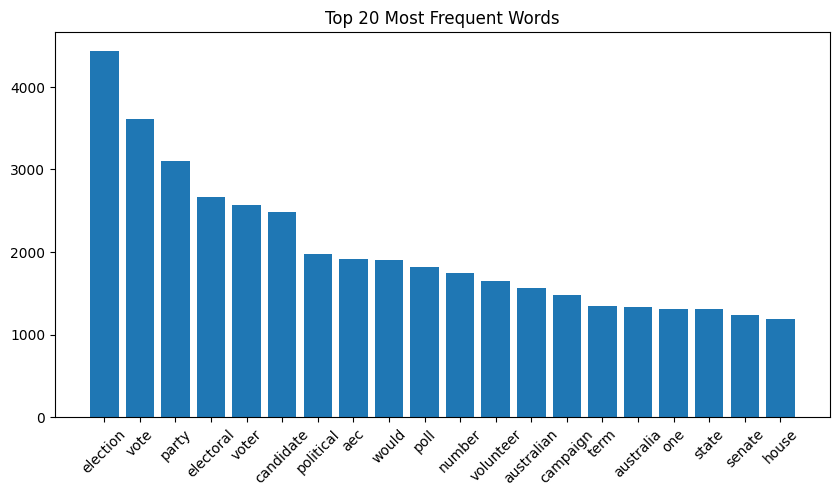

In [33]:
import matplotlib.pyplot as plt
word_freq = Counter(all_tokens)
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

In [34]:
keywords = ["integrity", "trust", "fraud", "transparency",
            "reform", "vote", "senate", "postal", "representation"]

for word in keywords:
    count = sum(word in tokens for tokens in analysis_df["tokens_lemmatized"])
    print(word, "appears in", count, "submissions")

integrity appears in 79 submissions
trust appears in 75 submissions
fraud appears in 6 submissions
transparency appears in 56 submissions
reform appears in 115 submissions
vote appears in 246 submissions
senate appears in 70 submissions
postal appears in 77 submissions
representation appears in 66 submissions


In [35]:
analysis_df["unique_words"] = analysis_df["tokens_lemmatized"].apply(lambda x: len(set(x)))
analysis_df["token_count"] = analysis_df["tokens_lemmatized"].apply(len)

analysis_df["lexical_diversity"] = analysis_df["unique_words"] / analysis_df["token_count"]

analysis_df[["filename", "lexical_diversity"]].sort_values("lexical_diversity", ascending=False).head()


,filename,lexical_diversity
262,Sub272 - Name Withheld.pdf,1.000000
290,SupSub093.1 - Name withheld.pdf,0.930736
69,Sub072 - Lynn Lawson.pdf,0.921569
214,Sub220 - David Bascomb.pdf,0.915254
9,Sub010 - Name withheld.pdf,0.907407


In [36]:
analysis_df.loc[290, ["token_count", "unique_words"]]

token_count     231
unique_words    215
Name: 290, dtype: int64

In [37]:
analysis_df.loc[262, ["token_count", "unique_words"]]

token_count     18
unique_words    18
Name: 262, dtype: int64

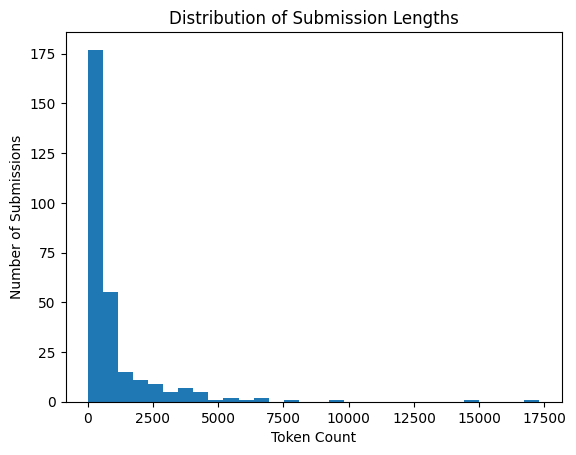

In [38]:
import matplotlib.pyplot as plt

plt.hist(analysis_df["token_count"], bins=30)
plt.title("Distribution of Submission Lengths")
plt.xlabel("Token Count")
plt.ylabel("Number of Submissions")
plt.show()

In [39]:
from nltk.util import ngrams
from collections import Counter

all_bigrams = []

for tokens in analysis_df["tokens_lemmatized"]:
    bigrams = list(ngrams(tokens, 2))
    all_bigrams.extend(bigrams)

bigram_freq = Counter(all_bigrams)

top_bigrams = bigram_freq.most_common(20)

top_bigrams
for bigram, count in top_bigrams:
    print(" ".join(bigram), ":", count)

federal election : 830
pre poll : 612
house representative : 543
political party : 534
per cent : 506
poll booth : 463
ballot paper : 449
electoral commission : 408
electoral matter : 401
australian electoral : 357
poll place : 354
committee electoral : 344
stand committee : 341
joint stand : 333
election day : 314
year term : 289
political advertising : 258
electoral act : 240
major party : 231
third party : 229


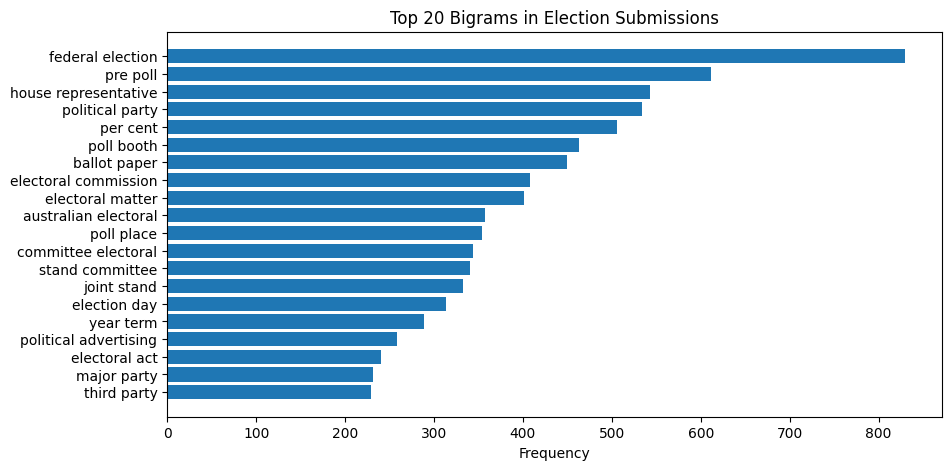

In [40]:
import matplotlib.pyplot as plt

phrases = [" ".join(b) for b, c in top_bigrams]
counts = [c for b, c in top_bigrams]

plt.figure(figsize=(10,5))
plt.barh(phrases, counts)
plt.title("Top 20 Bigrams in Election Submissions")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [41]:
all_trigrams = []

for tokens in analysis_df["tokens_lemmatized"]:
    trigrams = list(ngrams(tokens, 3))
    all_trigrams.extend(trigrams)

trigram_freq = Counter(all_trigrams)

top_trigrams = trigram_freq.most_common(15)

for trigram, count in top_trigrams:
    print(" ".join(trigram), ":", count)

committee electoral matter : 337
joint stand committee : 331
stand committee electoral : 322
australian electoral commission : 313
submission joint stand : 153
four year term : 150
truth political advertising : 143
commonwealth electoral act : 114
electoral commission aec : 107
new south wale : 96
v ot er : 88
state division ppvc : 81
division ppvc total : 81
ppvc total vote : 81
total vote day : 81


In [42]:
analysis_df["processed_text"] = analysis_df["tokens_lemmatized"].apply(lambda x: " ".join(x))

# check result
analysis_df[["filename","processed_text"]].head()

,filename,processed_text
0,Sub001 - Bob McMullan.pdf,time revisit territory representation introduc...
1,Sub002 - Dr Sheppard.pdf,possible solution money few core responsibilit...
2,Sub003 - Grattan Institute.pdf,submission september submission aruna sathanap...
3,Sub004 - Australian Electoral Commission.pdf,aec submission joint stand committee electoral...
4,Sub005 - The Australia Institute.pdf,australian democracy submission inquiry federa...


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

!pip install --upgrade scipy scikit-learn numpy
analysis_df["processed_text"] = analysis_df["tokens_lemmatized"].apply(lambda x: " ".join(x))

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

custom_stopwords = [
    "committee","joint","standing","submission","matter",
    "electoral","election","federal","australian","commission",
    "government","people","would","one","also","include"
]

vectorizer = TfidfVectorizer(
    stop_words='english',      # built-in stopwords
    max_features=2000,
    ngram_range=(1,2),         # bigrams help topics
    min_df=5,                  # must appear in ≥5 docs
    max_df=0.80
)

X = vectorizer.fit_transform(analysis_df["processed_text"])

# Feature names
feature_names = vectorizer.get_feature_names_out()

# Mean TF-IDF score across all submissions
mean_tfidf = np.asarray(X.mean(axis=0)).ravel()

# Top 20 distinctive terms/phrases
top_n = 20
top_idx = mean_tfidf.argsort()[::-1][:top_n]

tfidf_results = pd.DataFrame({
    "term": feature_names[top_idx],
    "mean_tfidf": mean_tfidf[top_idx]
})

print(tfidf_results)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
          term  mean_tfidf
0    volunteer    0.095474
1        party    0.071145
2        voter    0.070464
3         poll    0.070245
4    candidate    0.068255
5        booth    0.059205
6    electoral    0.058608
7          aec    0.050064
8     campaign    0.047302
9    political    0.046362
10      number    0.040672
11         day    0.037290
12        term    0.036410
13         pre    0.036284
14      people    0.035630
15   committee    0.035004
16  australian    0.034546
17    pre poll    0.034446
18   behaviour    0.033214
19   australia    0.031946


### 2. [Topic Modeling/ Clustering/ RegEx....]

[Create separate sections for each approach and number them accordingly. Follow the same template as above - description of method, well documented code block, results and charts, explanation of results in your own words]


What differences do you see in the methods you tried and their results? What are the advantages, and limitations of each approach?

In [54]:
from sklearn.feature_extraction.text import CountVectorizer

# Optional domain-specific stopwords to reduce header noise
custom_stopwords = [
    "committee", "joint", "standing", "submission", "matter",
    "electoral", "election", "federal", "australian", "commission",
    "aec"
]

vectorizer = CountVectorizer(
    stop_words=custom_stopwords,
    max_df=0.85,     # ignore words in too many documents
    min_df=3         # keep words appearing in at least 3 documents
)

dtm = vectorizer.fit_transform(analysis_df["processed_text"])

print("Document-term matrix shape:", dtm.shape)

Document-term matrix shape: (294, 5501)


In [55]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(dtm)

feature_names = vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_terms = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx + 1}: {', '.join(top_terms)}")

print_topics(lda, feature_names, n_top_words=10)

Topic 1: party, political, funding, australia, labor, er, campaign, independent, democracy, public
Topic 2: political, public, australia, include, people, democracy, party, government, act, process
Topic 3: vote, house, state, term, per, senate, would, number, year, senator
Topic 4: volunteer, poll, voter, party, candidate, booth, vote, campaign, pre, day
Topic 5: vote, system, ballot, paper, senate, number, candidate, voter, would, preference


In [56]:
topic_values = lda.transform(dtm)

analysis_df["dominant_topic"] = topic_values.argmax(axis=1) + 1

topic_counts = analysis_df["dominant_topic"].value_counts().sort_index()
print(topic_counts)

dominant_topic
1     11
2     64
3     28
4    177
5     14
Name: count, dtype: int64


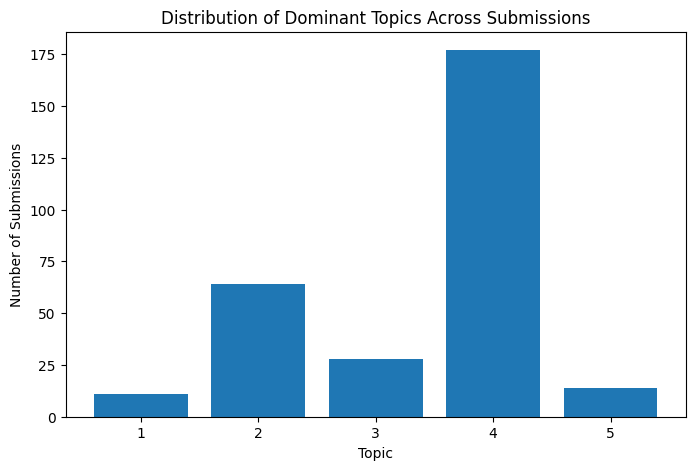

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.xlabel("Topic")
plt.ylabel("Number of Submissions")
plt.title("Distribution of Dominant Topics Across Submissions")
plt.show()

In [61]:
from sklearn.cluster import KMeans

k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

analysis_df["cluster"] = clusters
import numpy as np

terms = vectorizer.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    print(f"\nCluster {i} top words:")

    top_words = [terms[ind] for ind in order_centroids[i, :10]]

    print(", ".join(top_words))

    cluster_counts = analysis_df["cluster"].value_counts().sort_index()

print(cluster_counts)


Cluster 0 top words:
faq, desperate, february, amplify, deeply, diligently, anthony, dilute, alteration, anxious

Cluster 1 top words:
derogatory, briefly, deeply, blue, disinterested, approximately, air, abuse, achievable, assault

Cluster 2 top words:
faq, desperate, amplify, february, anxious, deeply, achievable, anthony, desperately, diligently

Cluster 3 top words:
alliance, anxious, briefly, feeling, february, achievable, deeply, diminished, decided, facility

Cluster 4 top words:
exactly, embarrassment, emotive, coincide, decision, first, duplication, cult, environmentally, except
cluster
0    63
1    42
2    88
3    62
4    39
Name: count, dtype: int64


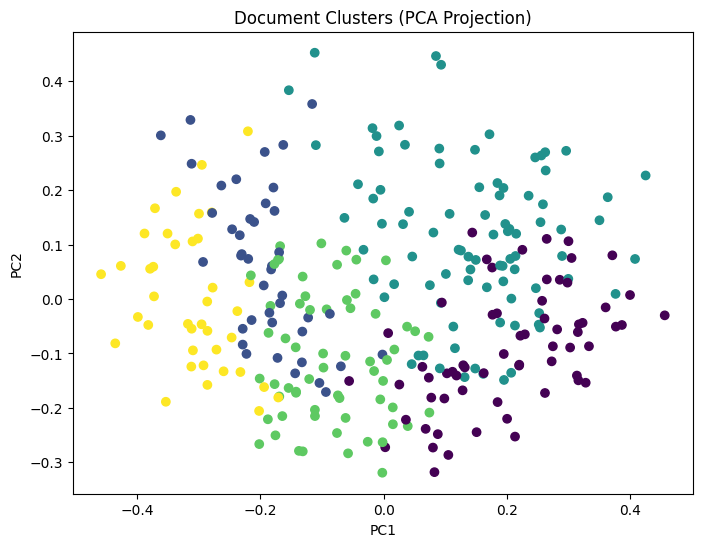

In [60]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=clusters, cmap='viridis')

plt.title("Document Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
!pip install textblob
from textblob import TextBlob




[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
    --------------------------------------- 10.2/624.3 kB ? eta -:--:--
   ------- -------------------------------- 122.9/624.3 kB 1.4 MB/s eta 0:00:01
   ------------------------------------ --- 563.2/624.3 kB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 3.9 MB/s eta 0:00:00


In [70]:
from textblob import TextBlob

analysis_df["subjectivity"] = analysis_df["clean_text"].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)
analysis_df.groupby("cluster")[["sentiment","subjectivity"]].mean()

,sentiment,subjectivity
cluster,,
0,0.069024,0.433785
1,0.067267,0.360018
2,0.071128,0.412757
3,0.073840,0.419579
4,0.097234,0.402261


### Conclusion

[Summary of findings from the data and any future recommended steps]

Your interpretive summary on the question provided (refer detailed assessment brief)

### References

[Add full list of references]